In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('Dataset.csv')

df = pd.DataFrame(data)

In [2]:
print(df.shape)

(45000, 15)


In [3]:
#cleaninig data
df = df.fillna(35.0)
df['Gender'] = df['Gender'].str.strip().str.lower()
df['Degree'] = df['Degree'].str.replace(r'\s+', '', regex=True).str.lower()
df['Branch'] = df['Branch'].str.strip().str.lower()
df['Placement_Status'] = df['Placement_Status'].str.strip().str.lower()

df_cleaned = df[
    (df['Age'].between(18, 25)) &
    (df['Gender'].isin(['male', 'female'])) &
    (df['Degree'].isin(['b.tech','bsc', 'mca', 'bca', 'b.sc'])) &
    (df['Branch'].isin(['me', 'civil', 'ece', 'cse', 'it'])) &
    (df['CGPA'].between(4, 10)) &
    (df['Internships'].isin([0, 1, 2, 3])) &
    (df['Projects'].between(1, 6)) &
    (df['Coding_Skills'].between(1, 10)) &
    (df['Communication_Skills'].between(1, 10)) &
    (df['Aptitude_Test_Score'].between(35.0, 100.0)) &
    (df['Soft_Skills_Rating'].between(1, 10)) &
    (df['Certifications'].isin([0, 1, 2, 3])) &
    (df['Backlogs'].isin([0, 1, 2, 3])) &
    (df['Placement_Status'].isin(['placed', 'not placed']))
].copy()

df_cleaned['Degree'] = df_cleaned['Degree'].replace('b.sc', 'bsc')

print(f"Original rows: {len(df)}")
print(f"Cleaned rows remaining: {len(df_cleaned)}")

Original rows: 45000
Cleaned rows remaining: 44995


In [4]:
print(df.loc[0])

Student_ID                    1048
Age                             22
Gender                      female
Degree                      b.tech
Branch                         ece
CGPA                          6.29
Internships                      0
Projects                         3
Coding_Skills                    4
Communication_Skills             6
Aptitude_Test_Score           51.0
Soft_Skills_Rating               5
Certifications                   1
Backlogs                         3
Placement_Status        not placed
Name: 0, dtype: object


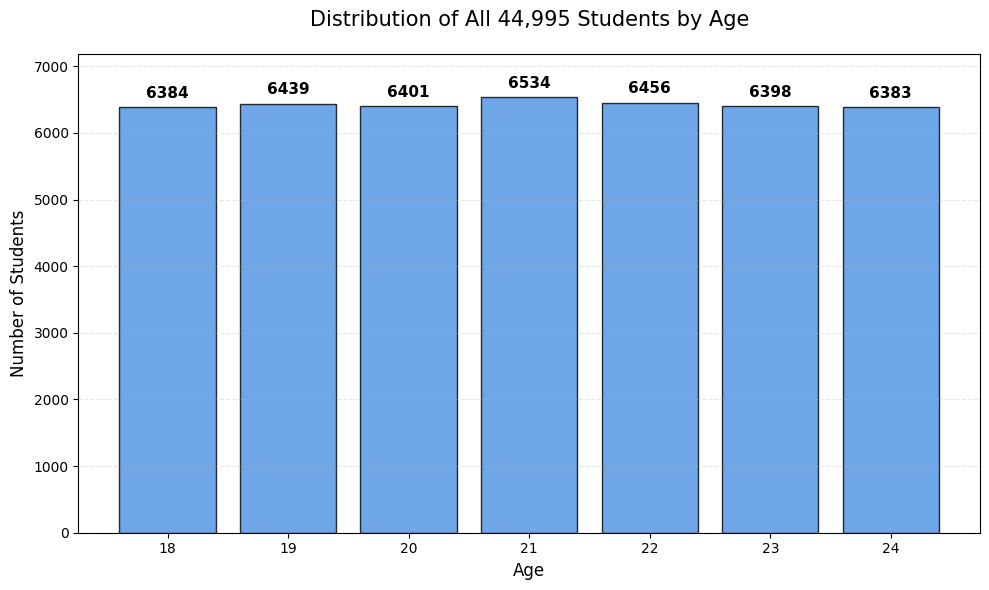

In [24]:
# age
# 1. Prepare the data
# We count how many times each age appears in our 44,995 rows
age_counts = df_cleaned['Age'].value_counts().sort_index()

# 2. Create the plot with a clear size
plt.figure(figsize=(10, 6))
bars = plt.bar(age_counts.index, age_counts.values, color='#4a90e2', edgecolor='black', alpha=0.8)

# 3. ADD DATA LABELS: This shows the exact number of rows in each bar
# This is how we "show" all 44,995 data points clearly
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, 
             f'{int(yval)}', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# 4. Styling for readability
plt.title('Distribution of All 44,995 Students by Age', fontsize=15, pad=20)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(age_counts.index) # Show 18, 19, 20... clearly
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust the limit so labels don't get cut off
plt.ylim(0, max(age_counts.values) * 1.1)

# 5. Display/Save
plt.tight_layout()
plt.savefig("Age_Distribution_Graph.png")
plt.show()

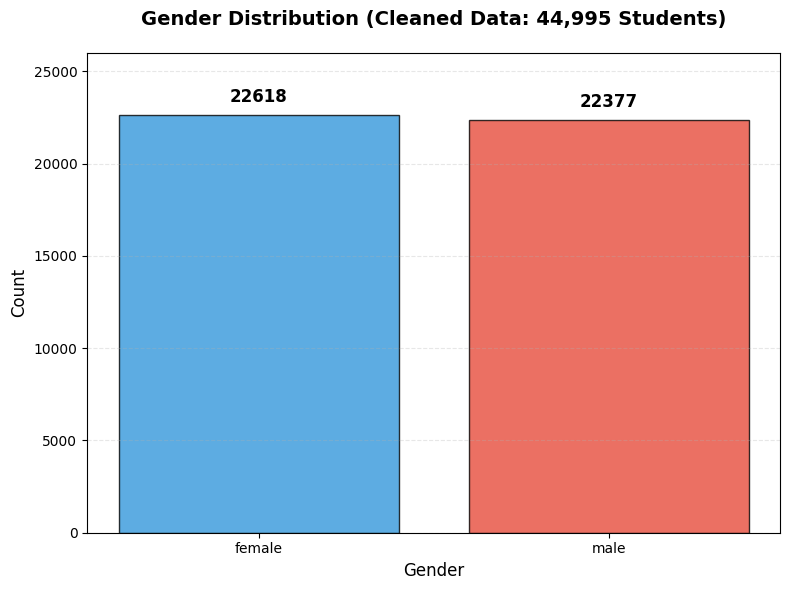

In [25]:
#gender
# 1. Prepare the data: Count occurrences of male and female
gender_counts = df_cleaned['Gender'].value_counts()

# 2. Define colors for the bars
colors = ['#3498db', '#e74c3c'] # Blue for first, Red/Pink for second

# 3. Create the Bar Graph
plt.figure(figsize=(8, 6))
bars = plt.bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='black', alpha=0.8)

# 4. Add Data Labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, 
             f'{int(yval)}', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# 5. Styling
plt.title('Gender Distribution (Cleaned Data: 44,995 Students)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ylim(0, max(gender_counts.values) * 1.15) # Add space for labels
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 6. Save the plot
plt.tight_layout()
plt.savefig("Gender_Distribution.png")
plt.show()

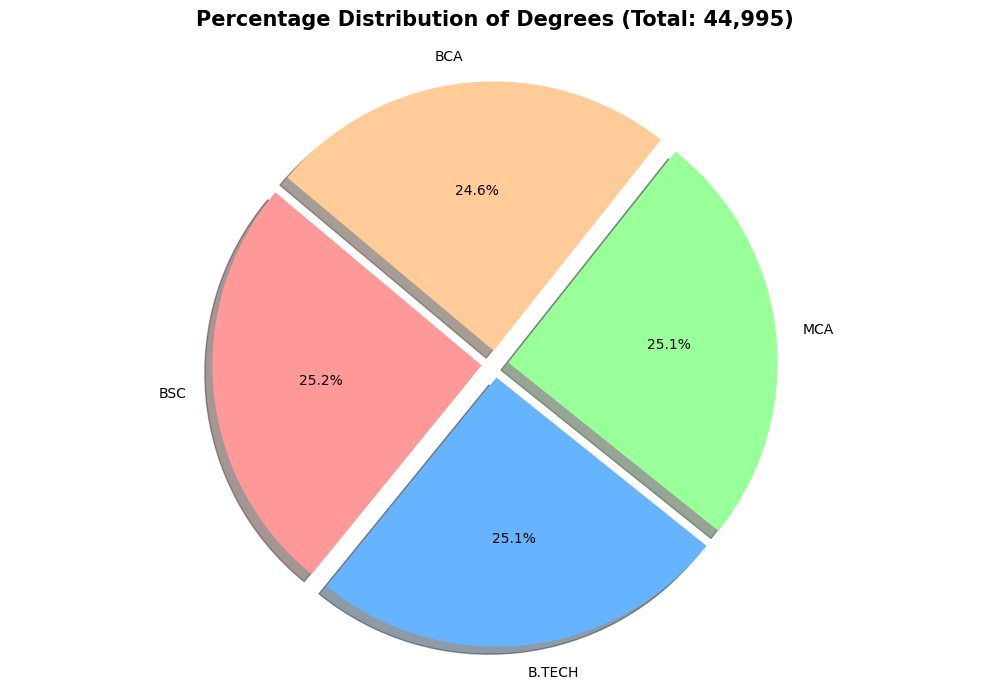

In [26]:
#degree
# 1. Prepare the data: Count occurrences of each degree
degree_counts = df_cleaned['Degree'].value_counts()

# 2. Create the Pie Chart
plt.figure(figsize=(10, 7))

# Define a professional color palette
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

# Create the pie
# 'autopct' shows the percentage of each slice
# 'startangle' rotates the start of the chart for better layout
plt.pie(degree_counts, 
        labels=degree_counts.index.str.upper(), 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=[0.05] * len(degree_counts), # Slightly separate slices for "watchability"
        shadow=True)

# 3. Styling
plt.title('Percentage Distribution of Degrees (Total: 44,995)', fontsize=15, fontweight='bold', pad=20)

# 4. Save the plot
plt.axis('equal') # Ensures the pie is drawn as a circle
plt.tight_layout()
plt.savefig("Percentage_Distribution_of_Degrees.png")
plt.show()

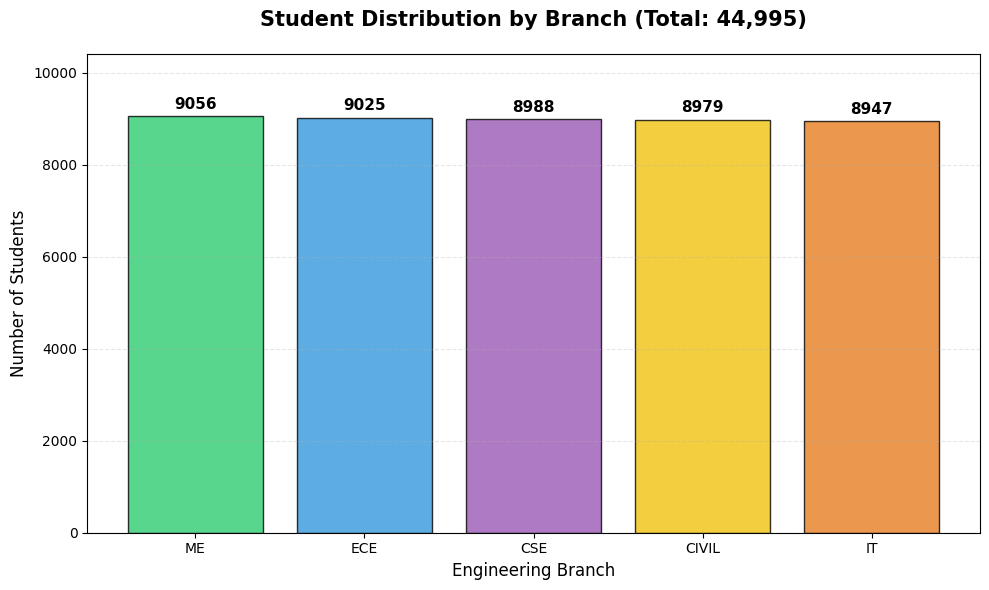

In [27]:
#branch
# 1. Prepare the data: Count occurrences of each branch
# We use .upper() in the labels so 'cse' becomes 'CSE' on the graph
branch_counts = df_cleaned['Branch'].value_counts()

# 2. Create the Bar Graph
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#f1c40f', '#e67e22'] # Different color for each branch

bars = plt.bar(branch_counts.index.str.upper(), branch_counts.values, 
                color=colors, edgecolor='black', alpha=0.8)

# 3. Add Data Labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, 
             f'{int(yval)}', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# 4. Styling for a professional look
plt.title('Student Distribution by Branch (Total: 44,995)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Engineering Branch', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add some breathing room at the top for labels
plt.ylim(0, max(branch_counts.values) * 1.15)

# 5. Save the plot
plt.tight_layout()
plt.savefig("Student_Distribution_By_Branch.png")
plt.show()

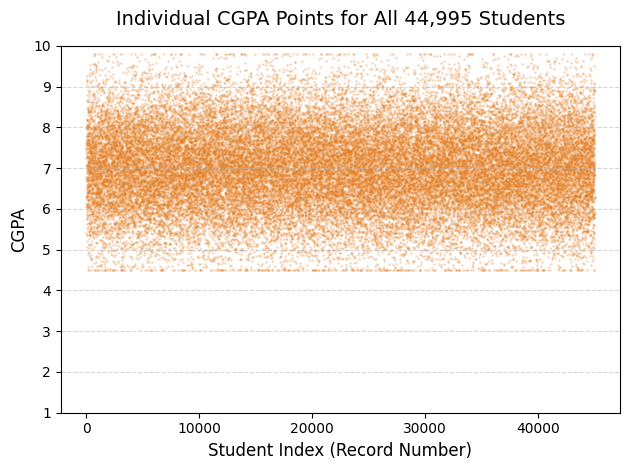

In [28]:
#cgpa
# 1. Create a Scatter Plot
# We use s=1 (tiny dots) and alpha=0.2 (transparent) 
# so 44,995 points don't just look like a solid block.
plt.scatter(df_cleaned.index, df_cleaned['CGPA'], s=1, alpha=0.2, color='#e67e22')

# 2. Set the Y-axis to exactly 1 to 10
plt.ylim(1, 10)

# 3. Add Labels and Title
plt.title('Individual CGPA Points for All 44,995 Students', fontsize=14, pad=15)
plt.xlabel('Student Index (Record Number)', fontsize=12)
plt.ylabel('CGPA', fontsize=12)

# 4. Add horizontal gridlines for easy reading of the scale
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Save the plot
plt.tight_layout()
plt.savefig("CGPA.png")
plt.show()

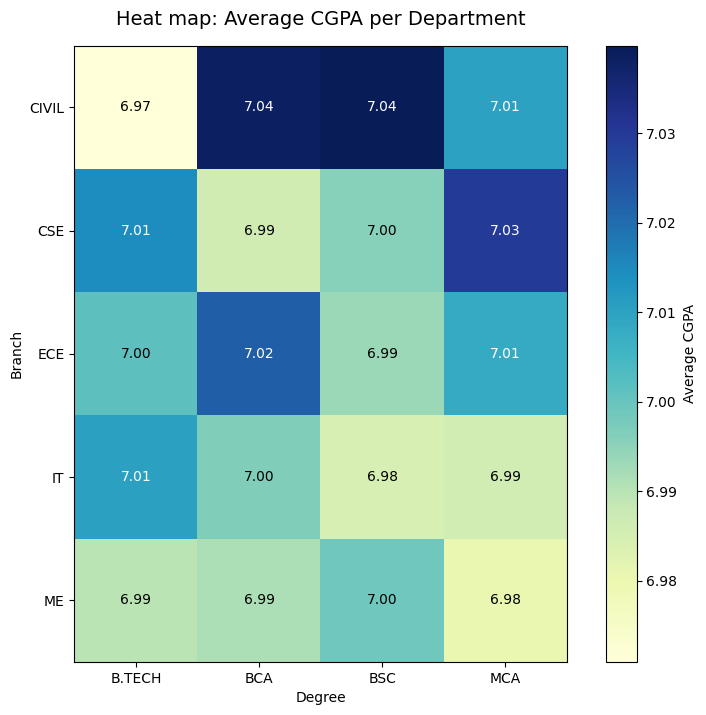

In [29]:
# 1. Create a pivot table for Branch vs Degree averages
pivot_table = df_cleaned.pivot_table(index='Branch', columns='Degree', values='CGPA', aggfunc='mean')

# 2. Plotting
plt.figure(figsize=(10, 8))
im = plt.imshow(pivot_table, cmap='YlGnBu') # Yellow to Blue
plt.colorbar(im, label='Average CGPA')

# 3. Add Category Labels
plt.xticks(range(len(pivot_table.columns)), pivot_table.columns.str.upper())
plt.yticks(range(len(pivot_table.index)), pivot_table.index.str.upper())

# 4. Annotate with the exact average values
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        val = pivot_table.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", 
                 color="white" if val > pivot_table.values.mean() else "black")

plt.xlabel('Degree')
plt.ylabel('Branch')
plt.title('Heat map: Average CGPA per Department', fontsize=14, pad=15)
plt.savefig('cgpa_department_heatmap.png')
plt.show()

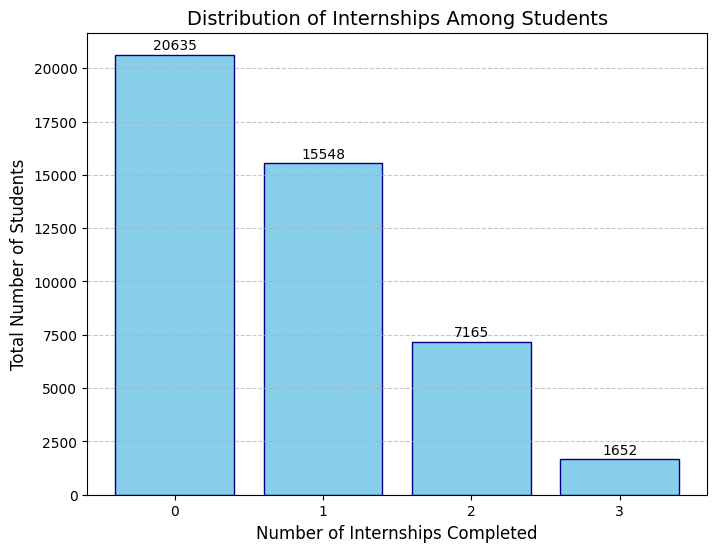

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Count the occurrences of each internship number
internship_counts = df['Internships'].value_counts().sort_index()

# 2. Create the plot
plt.figure(figsize=(8, 6))
bars = plt.bar(internship_counts.index.astype(str), internship_counts.values, color='skyblue', edgecolor='navy')

# 3. Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f'{int(yval)}', ha='center', va='bottom')

# 4. Formatting
plt.title('Distribution of Internships Among Students', fontsize=14)
plt.xlabel('Number of Internships Completed', fontsize=12)
plt.ylabel('Total Number of Students', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Save and Show
plt.savefig('internship_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

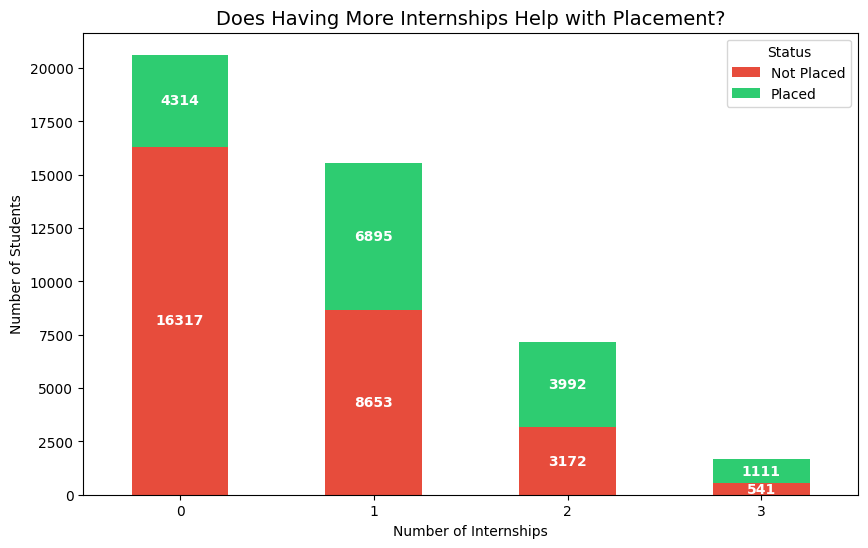

In [31]:
import matplotlib.pyplot as plt

# 1. Create the cross-tabulation
placed_interns = pd.crosstab(df_cleaned['Internships'], df_cleaned['Placement_Status'])

# 2. Plotting the stacked bar chart
ax = placed_interns.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#e74c3c', '#2ecc71'])

# 3. ADDING THE NUMBERS
# We iterate through the patches (the rectangles/bars)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    
    # Only add the label if the segment actually has a value (height > 0)
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white', # White looks better on red/green
                fontweight='bold',
                fontsize=10)

# 4. Styling
plt.title('Does Having More Internships Help with Placement?', fontsize=14)
plt.xlabel('Number of Internships')
plt.ylabel('Number of Students')
plt.legend(title='Status', labels=['Not Placed', 'Placed'])
plt.xticks(rotation=0)

plt.savefig('internships_vs_placement_with_numbers.png')
plt.show()

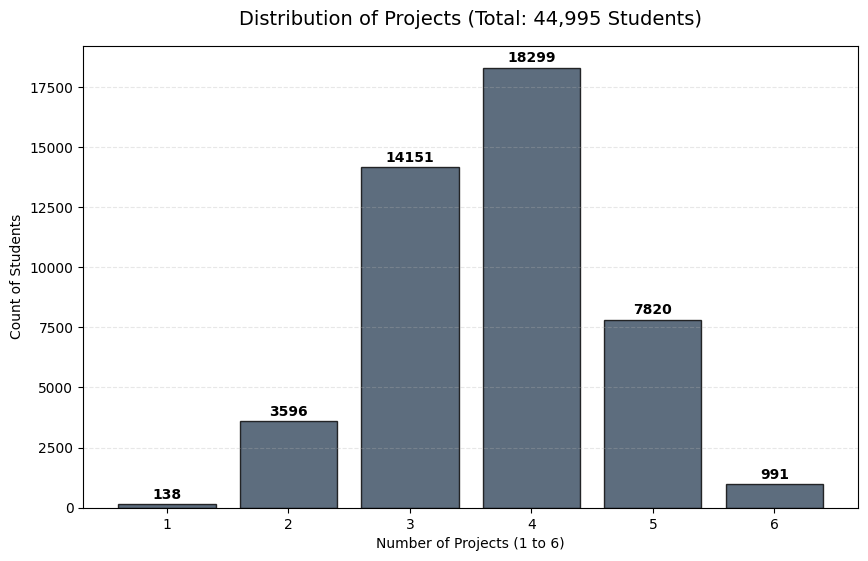

In [32]:
import matplotlib.pyplot as plt

# 1. Prepare data
project_counts = df_cleaned['Projects'].value_counts().sort_index()

# 2. Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(project_counts.index.astype(str), project_counts.values, 
                color='#34495e', edgecolor='black', alpha=0.8)

# 3. Add Labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, 
             f'{int(yval)}', ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Projects (Total: 44,995 Students)', fontsize=14, pad=15)
plt.xlabel('Number of Projects (1 to 6)')
plt.ylabel('Count of Students')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('project_distribution.png')
plt.show()

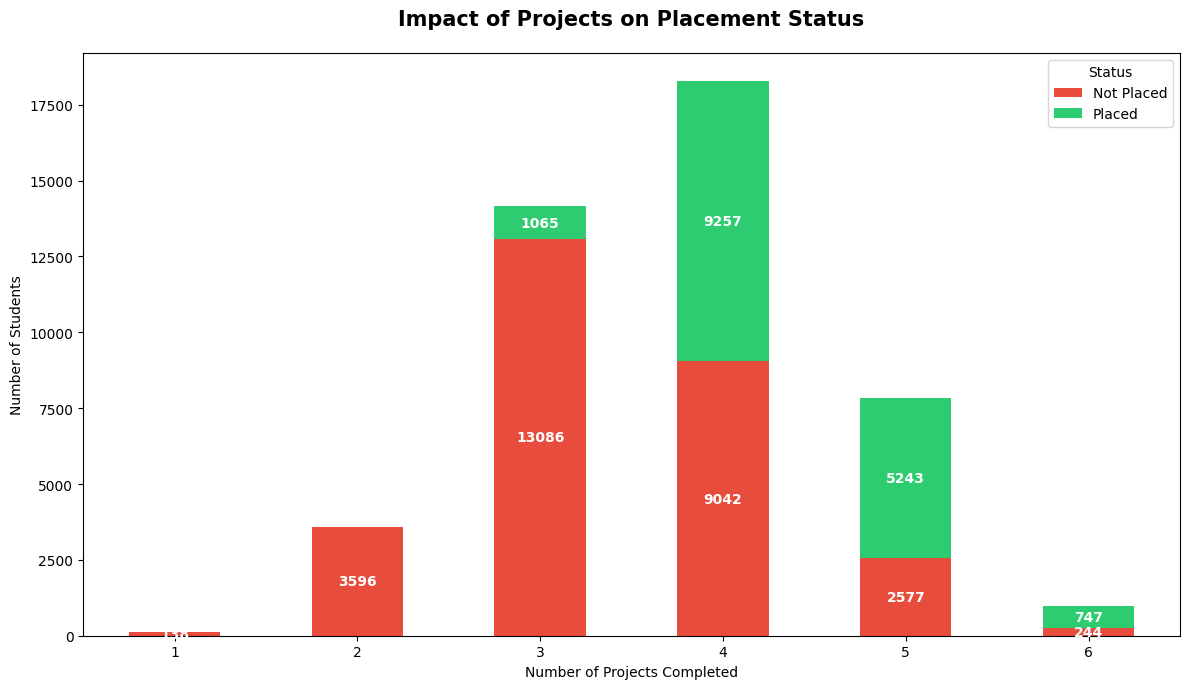

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create cross-tab
placed_projects = pd.crosstab(df_cleaned['Projects'], df_cleaned['Placement_Status'])

# 2. Plotting
ax = placed_projects.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#e74c3c', '#2ecc71'])

# 3. Add numbers inside the segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{int(height)}', 
                ha='center', va='center', color='white', fontweight='bold')

# 4. Styling
plt.title('Impact of Projects on Placement Status', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Number of Projects Completed')
plt.ylabel('Number of Students')
plt.legend(title='Status', labels=['Not Placed', 'Placed'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('projects_vs_placement.png')
plt.show()

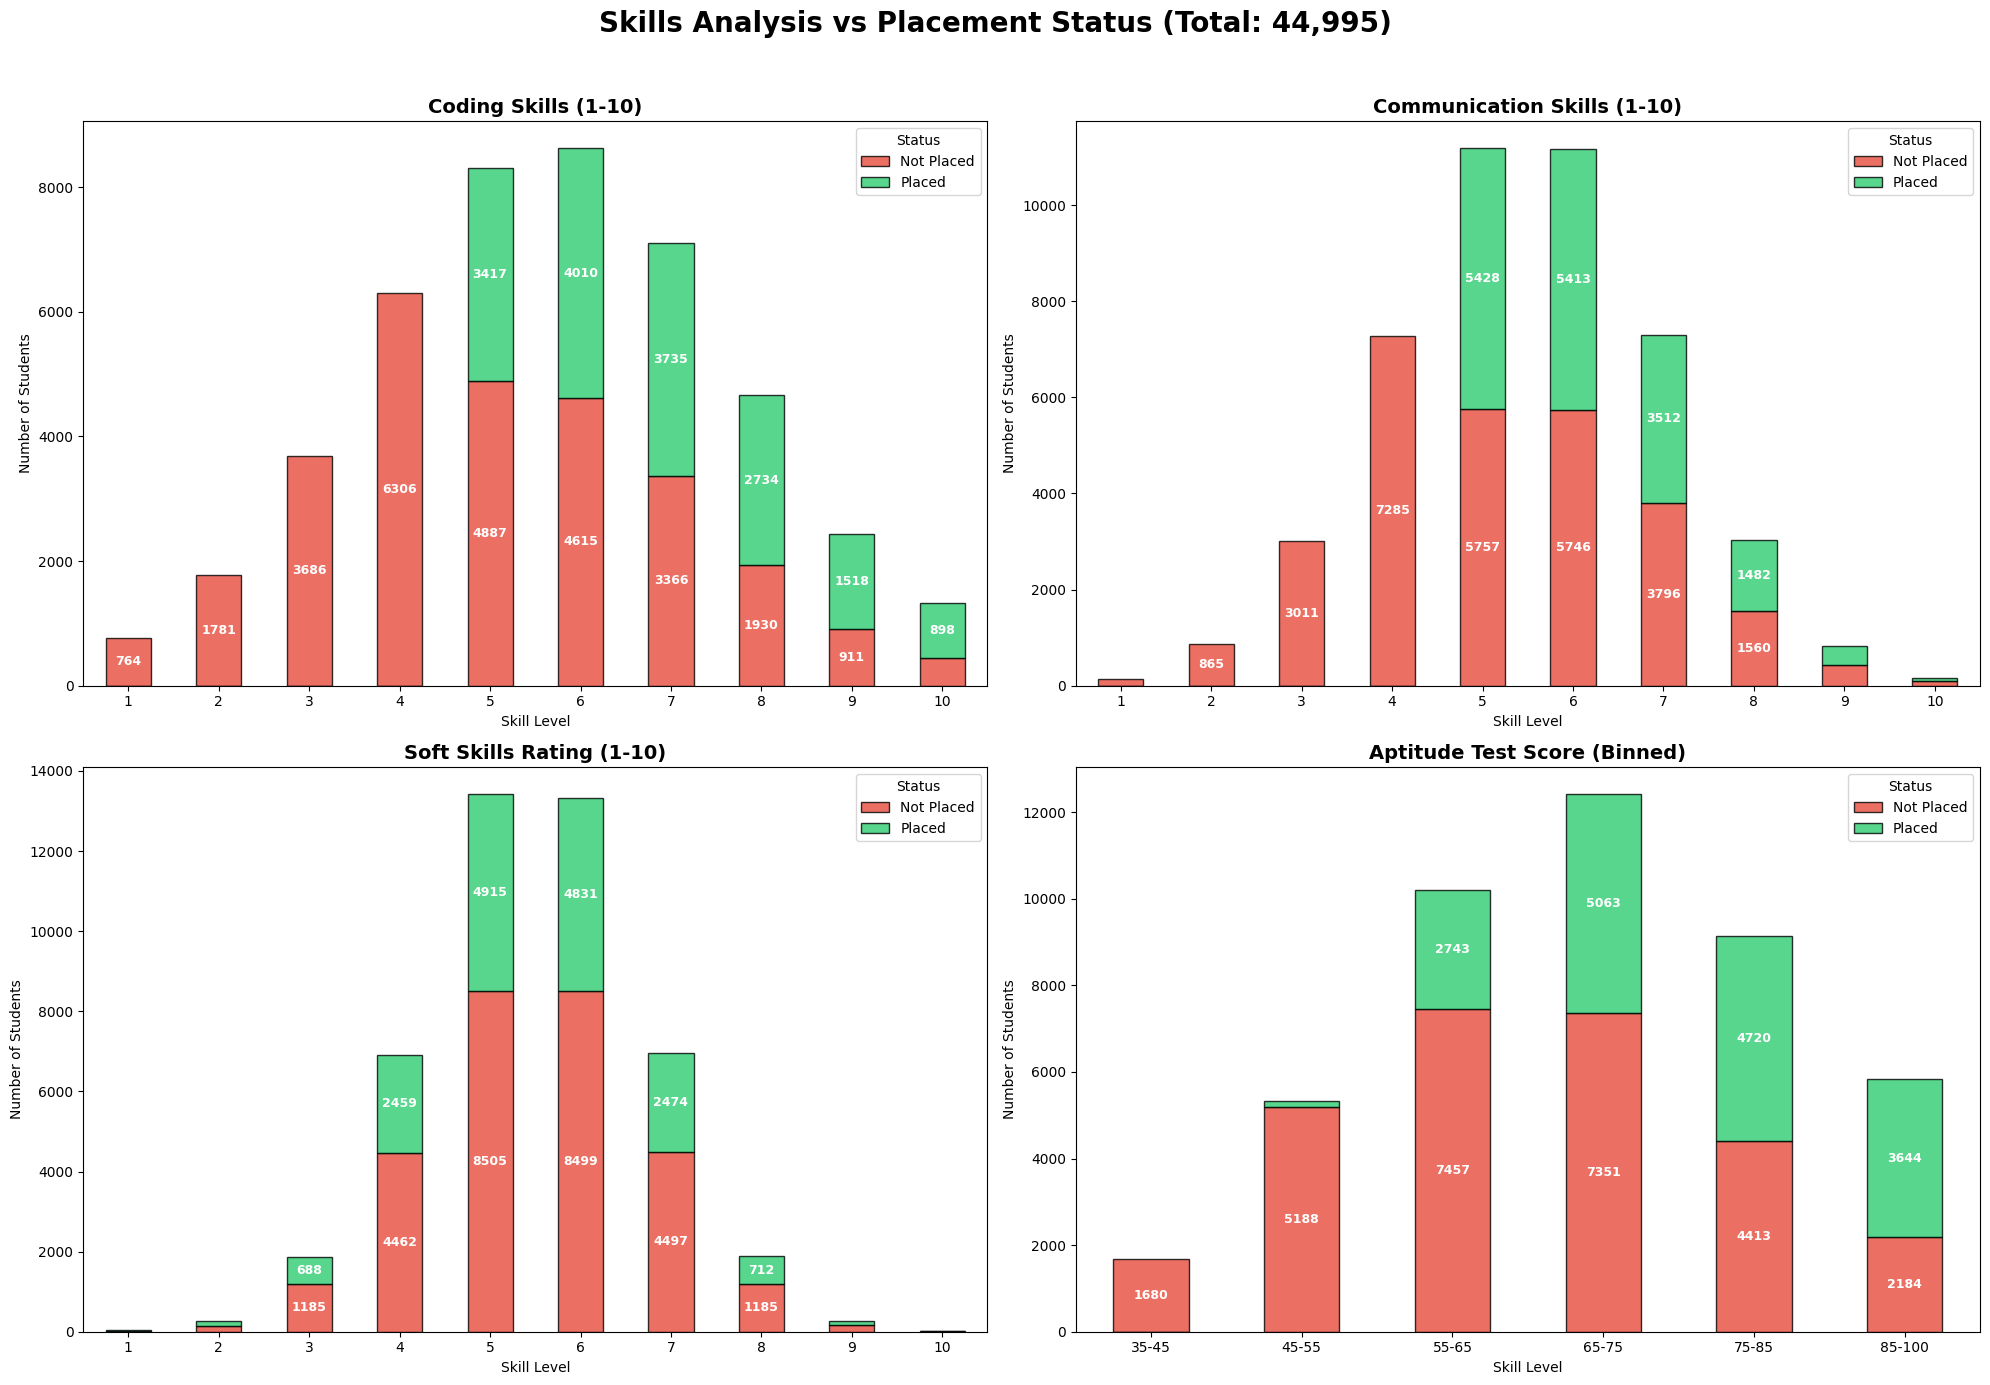

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Aptitude Bins (35-100)
bins = [35, 45, 55, 65, 75, 85, 100]
labels = ['35-45', '45-55', '55-65', '65-75', '75-85', '85-100']
df_cleaned['Aptitude_Bin'] = pd.cut(df_cleaned['Aptitude_Test_Score'], bins=bins, labels=labels)

# 2. Setup the 2x2 Figure
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Skills Analysis vs Placement Status (Total: 44,995)', fontsize=20, fontweight='bold', y=0.95)

# List of columns to plot
skills = ['Coding_Skills', 'Communication_Skills', 'Soft_Skills_Rating', 'Aptitude_Bin']
titles = ['Coding Skills (1-10)', 'Communication Skills (1-10)', 'Soft Skills Rating (1-10)', 'Aptitude Test Score (Binned)']
colors = ['#e74c3c', '#2ecc71'] # Red for Not Placed, Green for Placed

# 3. Loop through and create each subplot
for i, col in enumerate(skills):
    ax = axes[i//2, i%2]
    
    # Create crosstab
    ct = pd.crosstab(df_cleaned[col], df_cleaned['Placement_Status'])
    
    # Plot stacked bar
    ct.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', alpha=0.8)
    
    # Add numbers inside bars
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 500: # Only label if big enough to read
            ax.text(x + width/2, y + height/2, f'{int(height)}', 
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # Subplot styling
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel('Skill Level')
    ax.set_ylabel('Number of Students')
    ax.legend(title='Status', labels=['Not Placed', 'Placed'])
    ax.tick_params(axis='x', rotation=0)

# 4. Final adjustments and Save
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('combined_skills_analysis.png')
plt.show()

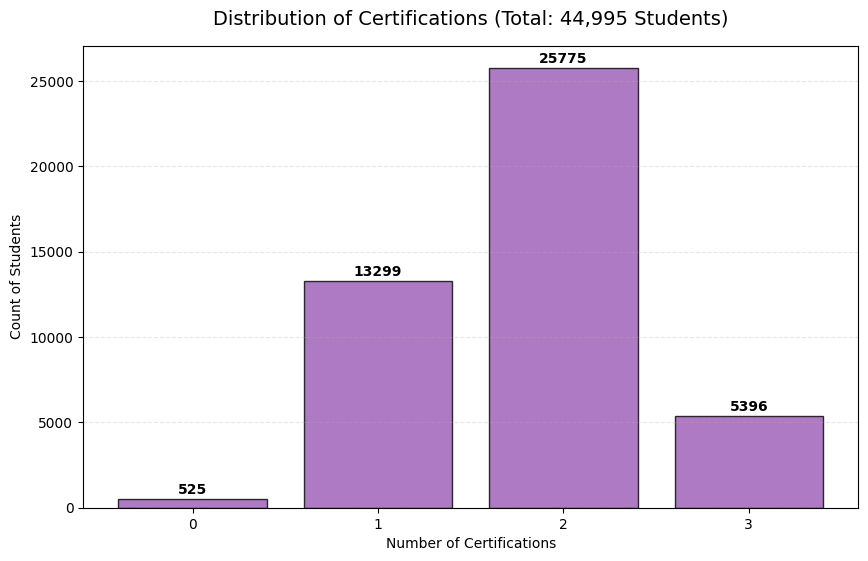

In [35]:
import matplotlib.pyplot as plt

# 1. Count the occurrences
cert_counts = df_cleaned['Certifications'].value_counts().sort_index()

# 2. Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(cert_counts.index.astype(str), cert_counts.values, 
                color='#9b59b6', edgecolor='black', alpha=0.8)

# 3. Add Data Labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, 
             f'{int(yval)}', ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Certifications (Total: 44,995 Students)', fontsize=14, pad=15)
plt.xlabel('Number of Certifications')
plt.ylabel('Count of Students')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('cert_distribution.png')
plt.show()

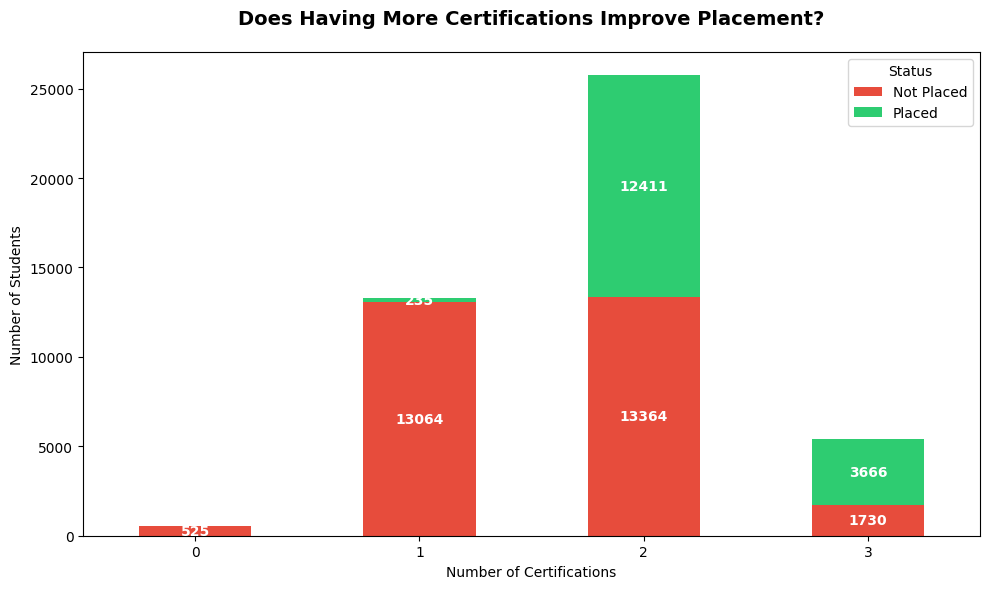

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the cross-tab
placed_certs = pd.crosstab(df_cleaned['Certifications'], df_cleaned['Placement_Status'])

# 2. Plotting the stacked bar
ax = placed_certs.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#e74c3c', '#2ecc71'])

# 3. Add numbers inside the segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{int(height)}', 
                ha='center', va='center', color='white', fontweight='bold')

# 4. Styling
plt.title('Does Having More Certifications Improve Placement?', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Certifications')
plt.ylabel('Number of Students')
plt.legend(title='Status', labels=['Not Placed', 'Placed'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('certs_vs_placement.png')
plt.show()

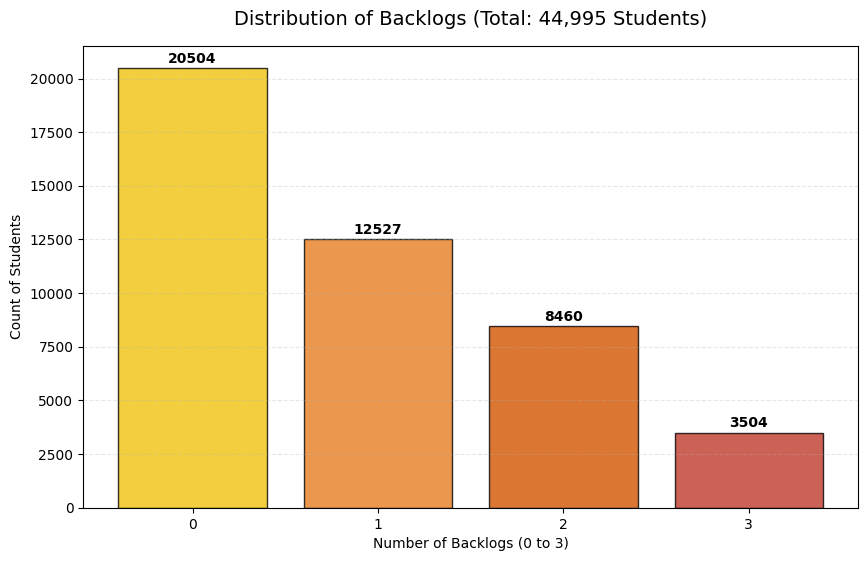

In [37]:
import matplotlib.pyplot as plt

# 1. Prepare data
backlog_counts = df_cleaned['Backlogs'].value_counts().sort_index()

# 2. Plotting
plt.figure(figsize=(10, 6))
colors = ['#f1c40f', '#e67e22', '#d35400', '#c0392b'] # Yellow to Dark Red (Warning colors)
bars = plt.bar(backlog_counts.index.astype(str), backlog_counts.values, 
                color=colors, edgecolor='black', alpha=0.8)

# 3. Add Labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, 
             f'{int(yval)}', ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Backlogs (Total: 44,995 Students)', fontsize=14, pad=15)
plt.xlabel('Number of Backlogs (0 to 3)')
plt.ylabel('Count of Students')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('backlog_distribution.png')
plt.show()

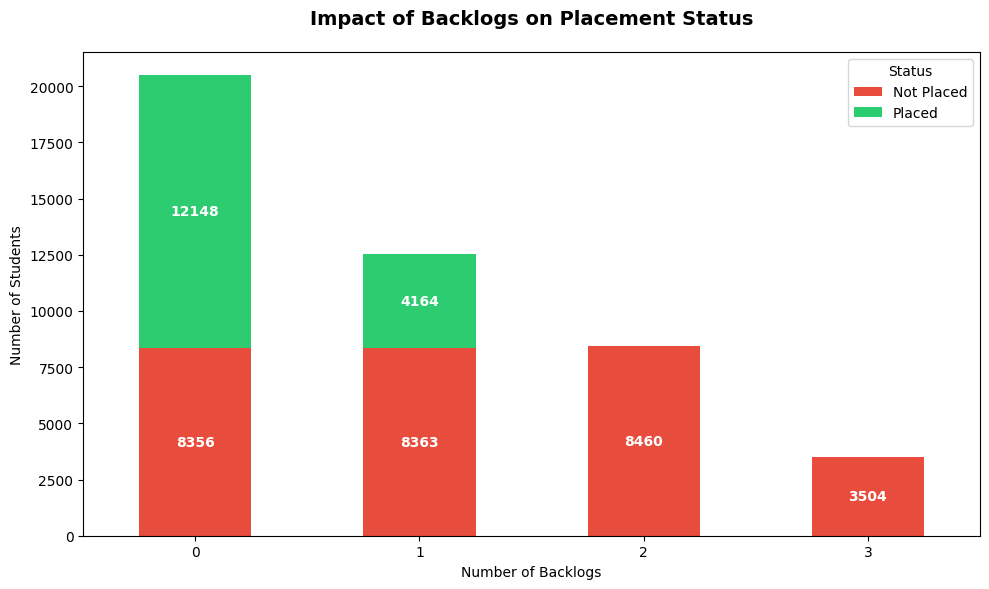

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create cross-tab
placed_backlogs = pd.crosstab(df_cleaned['Backlogs'], df_cleaned['Placement_Status'])

# 2. Plotting
ax = placed_backlogs.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#e74c3c', '#2ecc71'])

# 3. Add numbers inside the segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{int(height)}', 
                ha='center', va='center', color='white', fontweight='bold')

# 4. Styling
plt.title('Impact of Backlogs on Placement Status', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Backlogs')
plt.ylabel('Number of Students')
plt.legend(title='Status', labels=['Not Placed', 'Placed'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('backlogs_vs_placement.png')
plt.show()